In [ ]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import random
import torch
import torch.nn as nn
from huggingface_hub import HfApi
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm import tqdm


# Set all seeds for full reproducibility
def set_seed(seed: int = 42):
    """Set seeds for all sources of randomness"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: mps


In [11]:
@dataclass
class Config:
    image_size: int = 32
    num_classes: int = 100
    val_split: float = 0.1
    batch_size: int = 128
    epochs: int = 10
    lr: float = 8e-4
    weight_decay: float = 1e-4
    dropout: float = 0.1
    onnx_path: Path = Path("../data/mnist_cnn.onnx")
    opset_version: int = 17


cfg = Config()
print(f"Config: {cfg}")

Config: Config(image_size=32, num_classes=100, val_split=0.1, batch_size=128, epochs=10, lr=0.0008, weight_decay=0.0001, dropout=0.1, onnx_path=PosixPath('../data/mnist_cnn.onnx'), opset_version=17)


In [7]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(cfg.image_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomResizedCrop(
            cfg.image_size, scale=(0.9, 1.1), ratio=(1.0, 1.0)
        ),
    ]
)

train_val_dataset = datasets.CIFAR100(
    root="../data/", train=True, download=True, transform=transform
)
test_dataset = datasets.CIFAR100(
    root="../data/", train=False, download=True, transform=transform
)

# Merge datasets
merged_dataset = torch.utils.data.ConcatDataset([train_val_dataset, test_dataset])
total_size = len(merged_dataset)

# Calculate split sizes for 0.8 / 0.1 / 0.1
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# First split: train+val vs test
train_val_split, test_split = torch.utils.data.random_split(
    merged_dataset,
    [train_size + val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

# Second split: train vs val
train_split, val_split = torch.utils.data.random_split(
    train_val_split,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = torch.utils.data.DataLoader(
    train_split,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = torch.utils.data.DataLoader(
    val_split,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = torch.utils.data.DataLoader(
    test_split,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"Train size: {len(train_split)} ({len(train_split) / total_size:.1%})")
print(f"Val size: {len(val_split)} ({len(val_split) / total_size:.1%})")
print(f"Test size: {len(test_split)} ({len(test_split) / total_size:.1%})")

/Users/karan/Code/projects/zoo/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train size: 48000 (80.0%)
Val size: 6000 (10.0%)
Test size: 6000 (10.0%)


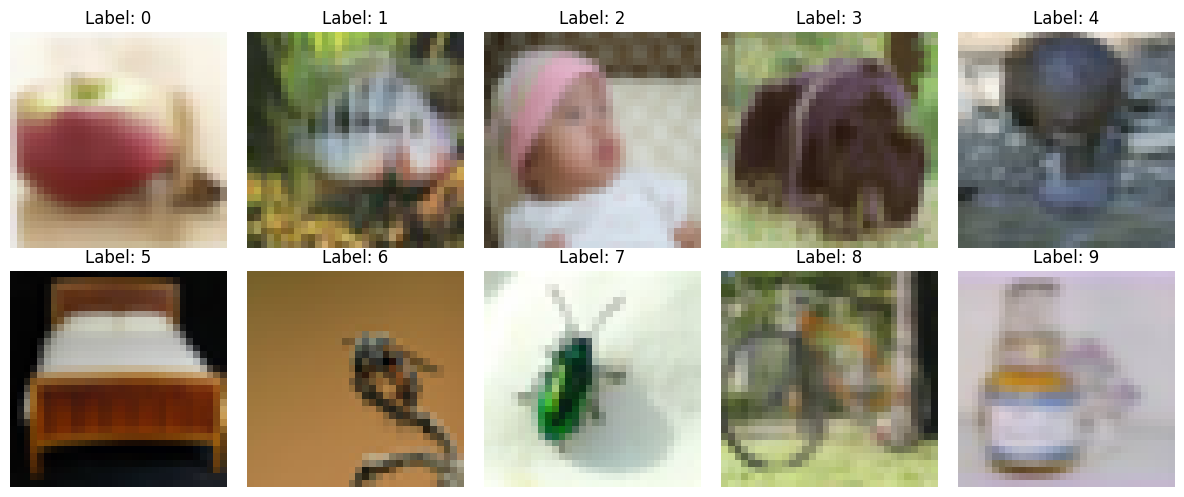

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

digit_indices = {}
for idx, (img, label) in enumerate(train_val_dataset):
    if label not in digit_indices:
        digit_indices[label] = idx
    if len(digit_indices) == 100:
        break

for digit in range(10):
    img, label = train_val_dataset[digit_indices[digit]]
    axes[digit].imshow(img.squeeze().permute(1, 2, 0))
    axes[digit].set_title(f"Label: {label}")
    axes[digit].axis("off")

plt.tight_layout()
plt.show()

In [39]:
class LayerNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.weight.view(1, -1, 1, 1) * x_normalized


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, m: int = 1):
        super().__init__()
        self.dw = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=5,
            padding=2,
            groups=in_channels,
            bias=False,
        )
        self.conv1 = nn.Conv2d(in_channels, out_channels * m, kernel_size=1)
        self.conv2 = nn.Conv2d(out_channels * m, out_channels, kernel_size=1)

        self.act = nn.GELU()
        self.norm = nn.GroupNorm(
            num_groups=4 if in_channels >= 4 else 1, num_channels=in_channels
        )

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )
        self.res_scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        residual = self.skip(x)
        x = self.norm(self.dw(x))
        x = self.conv2(self.act(self.conv1(x)))
        return x + residual * self.res_scale


class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = ConvBlock(3, 16)
        self.block2 = ConvBlock(16, 32)
        self.block3 = nn.Sequential(
            ConvBlock(32, 32), ConvBlock(32, 32), ConvBlock(32, 32)
        )
        self.block4 = ConvBlock(32, 32)
        self.classifier = nn.Linear(32 * 2 * 2, num_classes)
        self.down = nn.MaxPool2d(2)

    def normalize_inputs(self, x):
        # normalize each image to mean 0, and std 1
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-6
        return (x - mean) / std

    def forward(self, x):
        x = self.normalize_inputs(x)
        x = self.down(self.block1(x))
        x = self.down(self.block2(x))
        x = self.down(self.block3(x))
        x = self.down(self.block4(x))
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


model = Model(num_classes=cfg.num_classes).to(DEVICE)
summary(
    model, input_size=(1, 3, cfg.image_size, cfg.image_size), device=DEVICE, depth=1
)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1, 100]                  --
├─ConvBlock: 1-1                         [1, 16, 32, 32]           482
├─MaxPool2d: 1-2                         [1, 16, 16, 16]           --
├─ConvBlock: 1-3                         [1, 32, 16, 16]           2,577
├─MaxPool2d: 1-4                         [1, 32, 8, 8]             --
├─Sequential: 1-5                        [1, 32, 8, 8]             8,931
├─MaxPool2d: 1-6                         [1, 32, 4, 4]             --
├─ConvBlock: 1-7                         [1, 32, 4, 4]             2,977
├─MaxPool2d: 1-8                         [1, 32, 2, 2]             --
├─Linear: 1-9                            [1, 100]                  12,900
Total params: 27,867
Trainable params: 27,867
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.76
Input size (MB): 0.01
Forward/backward pass size (MB): 0.92
Params size (MB): 0.11
Estimated Total Si

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)


@torch.inference_mode()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

In [41]:
for epoch in range(cfg.epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{cfg.epochs}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # # clip norms
        # grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        pbar.set_postfix_str(
            f"loss: {loss.item():.4f}, acc: {(outputs.argmax(dim=1) == labels).float().mean().item():.4f}, lr: {scheduler.get_last_lr()[0]:.2e}, grad_norm: {grad_norm:.4f}"
        )

        break

    val_loss, val_acc = evaluate(val_loader)
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    scheduler.step()

    break

Epoch 1/10:   0%|          | 0/375 [00:00<?, ?it/s, loss: 4.6280, acc: 0.0000, lr: 8.00e-04, grad_norm: 0.4259]


Val Loss: 4.6183, Val Acc: 0.0093


In [42]:
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 4.6162
Test Accuracy: 0.0095


In [43]:
# show model's gradient flow
def print_grad_flow(model, csv=False, weight=True, bias=True):
    if csv:
        print(
            "name,grad_mean,grad_std,grad_max,grad_min,grad_norm,weight_norm,ratio,num_zeros"
        )
        for name, param in model.named_parameters():
            if param.grad is not None:
                if not weight and "weight" in name or not bias and "bias" in name:
                    continue
                grad_mean = param.grad.mean()
                grad_std = param.grad.std()
                grad_max = param.grad.max()
                grad_min = param.grad.min()
                grad_norm = param.grad.norm()
                weight_norm = param.norm()
                ratio = grad_norm / (weight_norm + 1e-6)
                num_zeros = (param.grad == 0).sum().item()

                print(
                    f"{name},{grad_mean:.4f},{grad_std:.4f},{grad_max:.4f},{grad_min:.4f},{grad_norm:.4f},{weight_norm:.4f},{ratio:.4f},{num_zeros}"
                )
    else:
        print(
            f"{'Name':<30} {'Grad Mean':>15} {'Grad Std':>15} {'Grad Max':>15} {'Grad Min':>15} {'Grad Norm':>15} {'Weight Norm':>15} {'Ratio':>15} {'Num Zeros':>12}"
        )
        for name, param in model.named_parameters():
            if param.grad is not None:
                if not weight and "weight" in name or not bias and "bias" in name:
                    continue

                grad_mean = param.grad.mean()
                grad_std = param.grad.std()
                grad_max = param.grad.max()
                grad_min = param.grad.min()
                grad_norm = param.grad.norm()
                weight_norm = param.norm()
                ratio = grad_norm / (weight_norm + 1e-6)
                num_zeros = (param.grad == 0).sum().item()

                print(
                    f"{name:<30} {grad_mean:>15.4f} {grad_std:>15.4f} {grad_max:>15.4f} {grad_min:>15.4f} {grad_norm:>15.4f} {weight_norm:>15.4f} {ratio:>15.4f} {num_zeros:>12}"
                )


print_grad_flow(model, csv=True)

name,grad_mean,grad_std,grad_max,grad_min,grad_norm,weight_norm,ratio,num_zeros
block1.res_scale,0.0106,nan,0.0106,0.0106,0.0106,0.0992,0.1067,0
block1.dw.weight,-0.0042,0.0137,0.0257,-0.0278,0.1229,1.0279,0.1196,0
block1.conv1.weight,0.0002,0.0040,0.0143,-0.0078,0.0274,2.5366,0.0108,0
block1.conv1.bias,-0.0001,0.0030,0.0038,-0.0059,0.0117,1.3459,0.0087,0
block1.conv2.weight,-0.0003,0.0044,0.0165,-0.0138,0.0711,2.3431,0.0303,0
block1.conv2.bias,-0.0009,0.0054,0.0059,-0.0095,0.0212,0.5717,0.0370,0
block1.norm.weight,-0.0004,0.0027,0.0015,-0.0036,0.0040,1.7316,0.0023,0
block1.norm.bias,0.0004,0.0023,0.0020,-0.0022,0.0034,0.0014,2.4231,0
block1.skip.weight,-0.0005,0.0013,0.0024,-0.0033,0.0092,2.3627,0.0039,0
block1.skip.bias,-0.0001,0.0005,0.0006,-0.0009,0.0021,1.7037,0.0012,0
block2.res_scale,-0.0035,nan,-0.0035,-0.0035,0.0035,0.1008,0.0352,0
block2.dw.weight,-0.0011,0.0050,0.0134,-0.0166,0.1024,2.2469,0.0456,0
block2.conv1.weight,-0.0000,0.0031,0.0089,-0.0115,0.0711,3.3200,0.0214,0
bloc

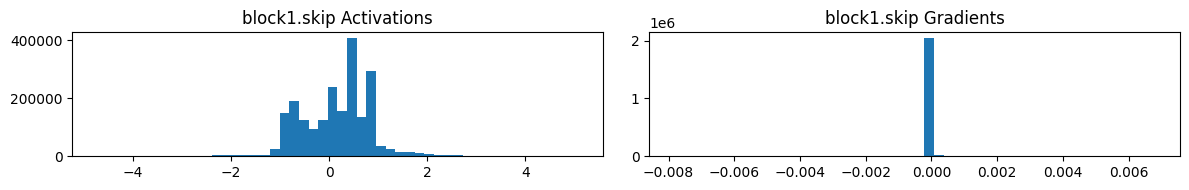

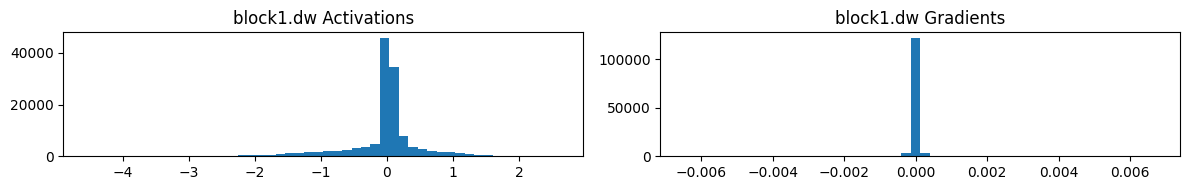

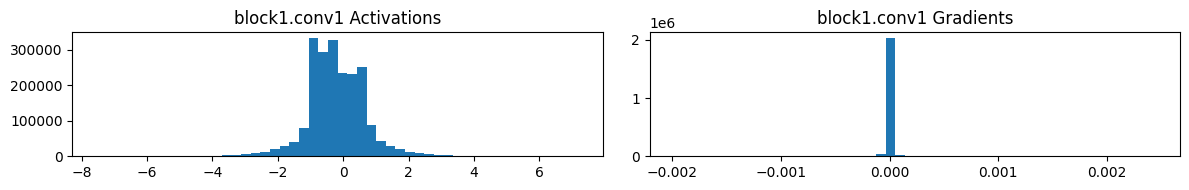

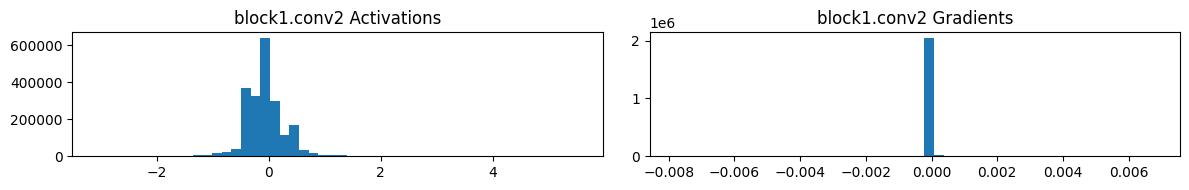

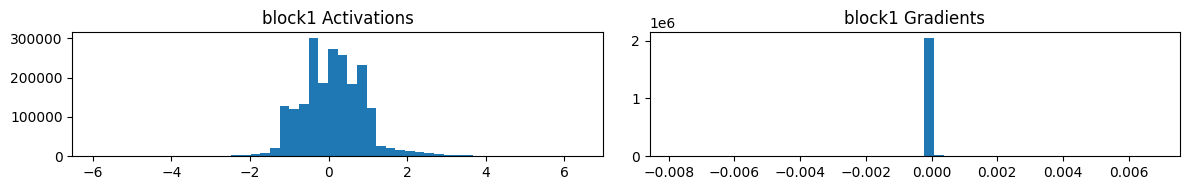

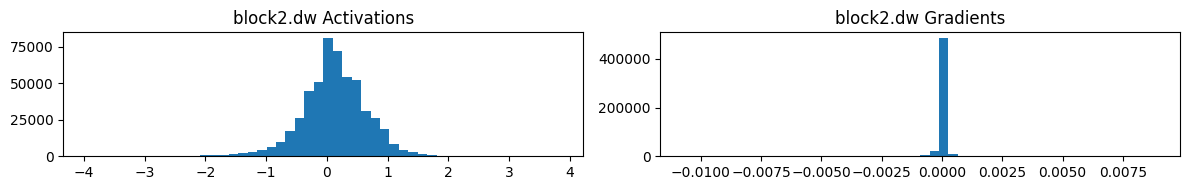

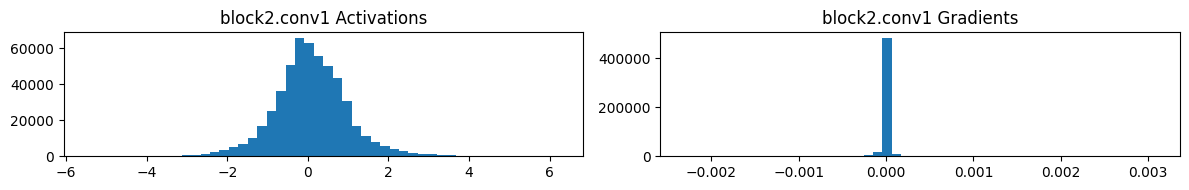

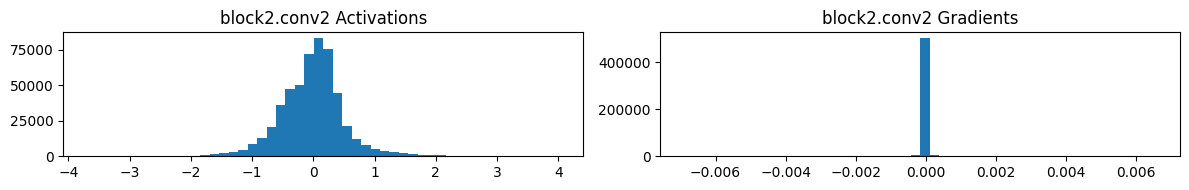

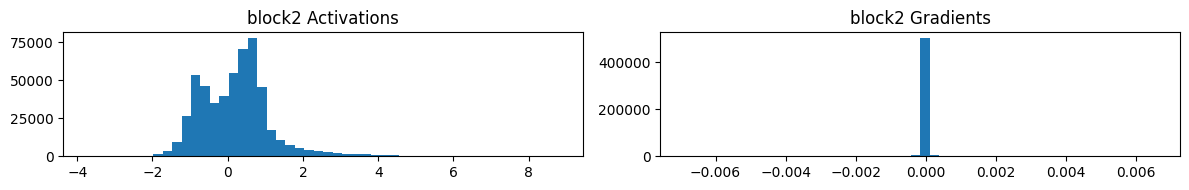

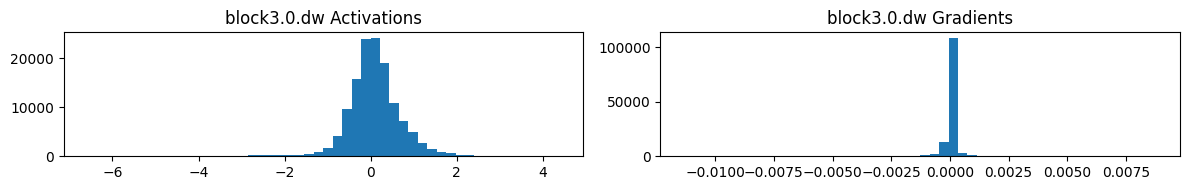

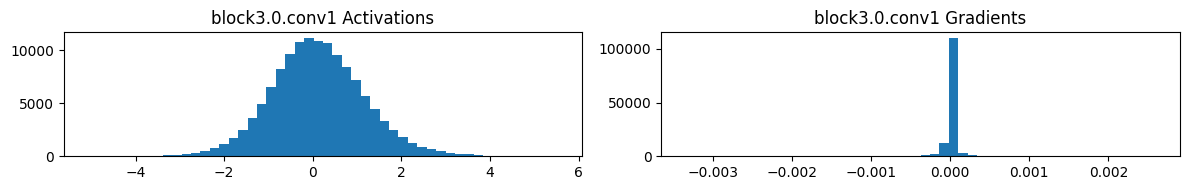

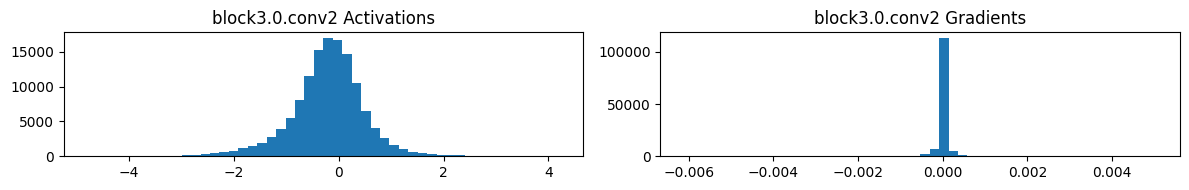

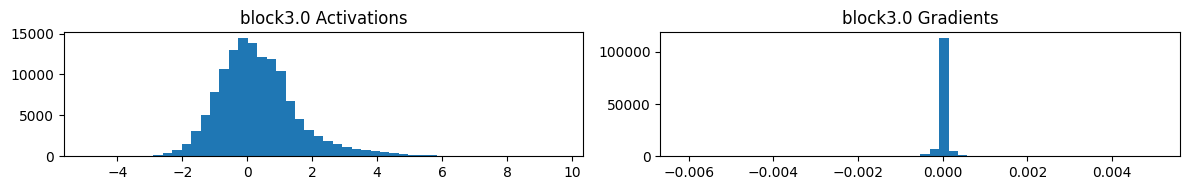

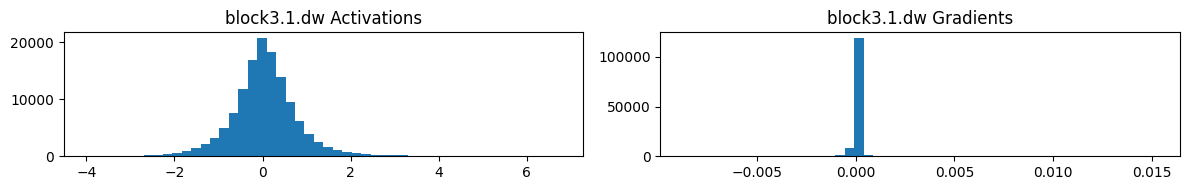

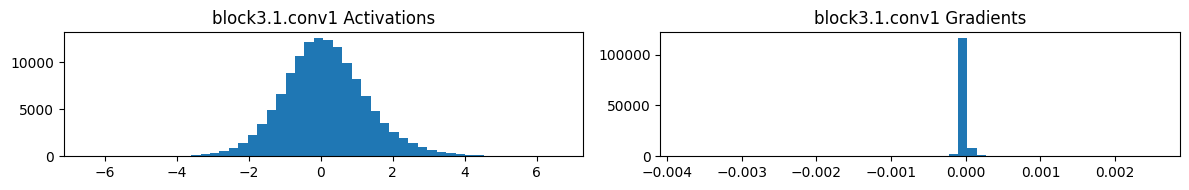

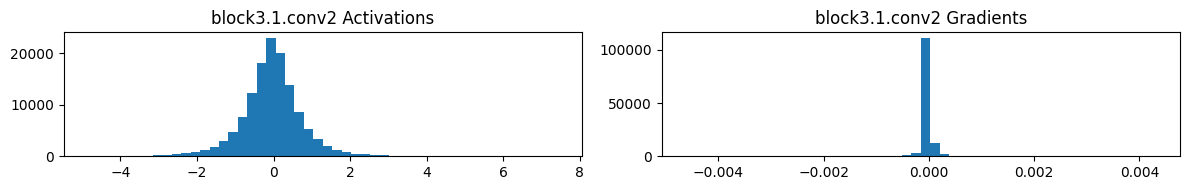

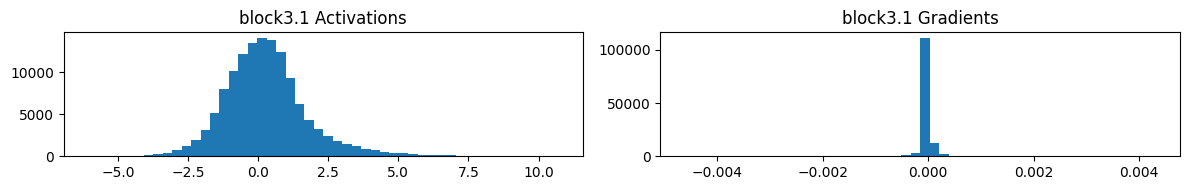

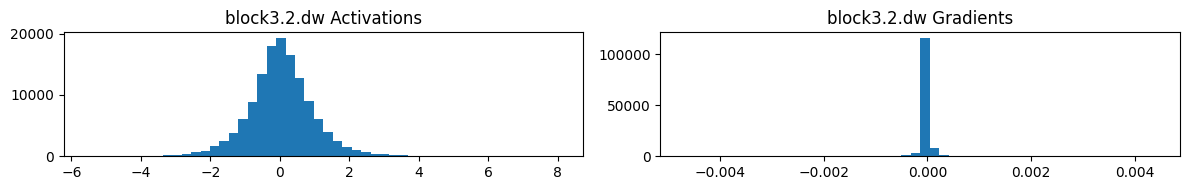

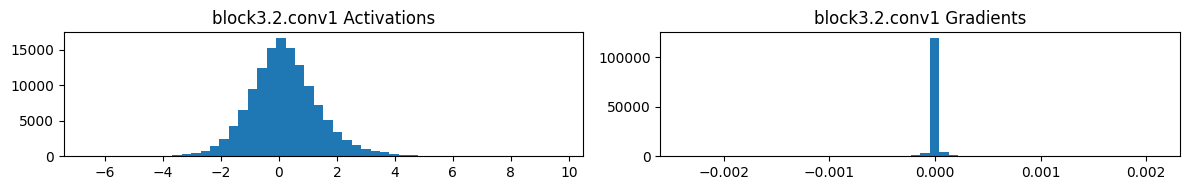

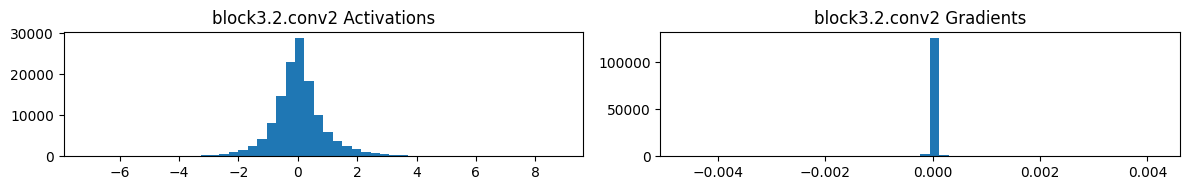

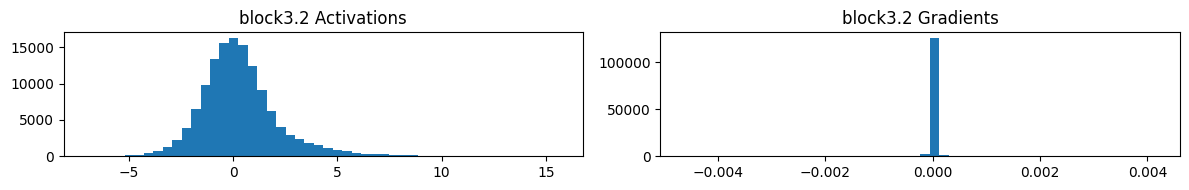

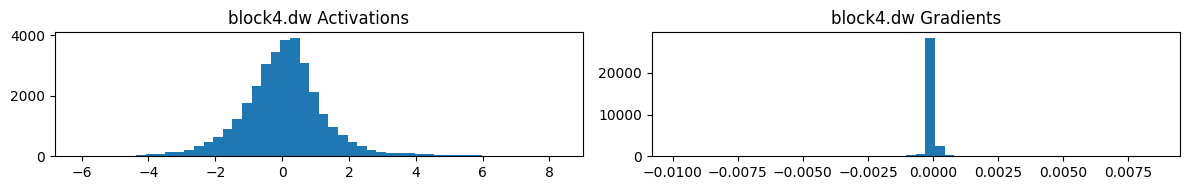

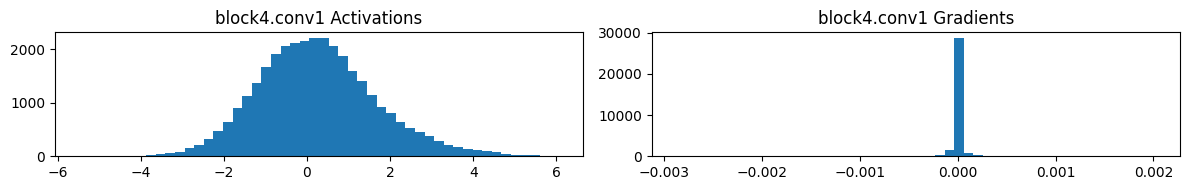

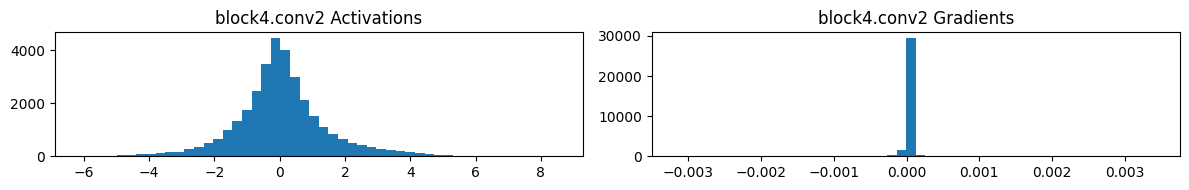

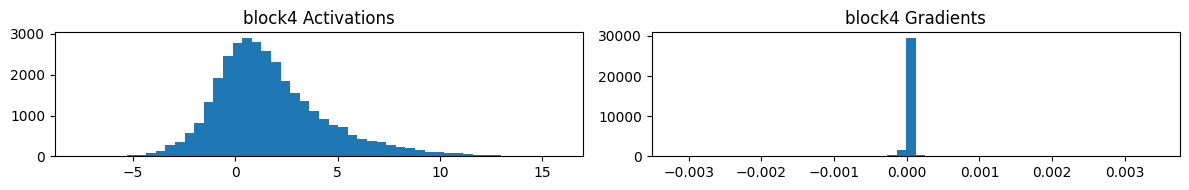

In [9]:
activations = {}
gradients = {}


def hook_fn(module, input, output):
    module_name = module._hook_name  # set below
    if module_name not in activations:
        activations[module_name] = []
        gradients[module_name] = []

    # Register backward hook for gradients BEFORE detaching
    if output.requires_grad:
        output.retain_grad()

        def grad_hook(grad):
            gradients[module_name].append(grad.detach().cpu())

        output.register_hook(grad_hook)

    # Now store activations (detached)
    activations[module_name].append(output.detach().cpu())


# Register hooks only on Conv2d layers (or your custom blocks)
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, ConvBlock):
        module._hook_name = name  # attach unique name for each module
        module.register_forward_hook(hook_fn)

# IMPORTANT: Set model to train mode to enable gradient computation
model.train()

# Run a batch of data through the model to collect activations and gradients
with torch.enable_grad():  # Explicitly enable gradients
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        break  # Only run one batch

# Plot activations and gradients
for module_name in activations:
    acts = activations[module_name]
    # Only plot if all activations have the same shape except for batch dim
    shapes = [a.shape for a in acts]
    base_shape = shapes[0][1:]  # skip batch dim
    if all(s[1:] == base_shape for s in shapes):
        act = torch.cat(acts, dim=0)
        grad = (
            torch.cat(gradients[module_name], dim=0) if gradients[module_name] else None
        )

        plt.figure(figsize=(12, 2))
        plt.subplot(1, 2, 1)
        plt.title(f"{module_name} Activations")
        plt.hist(act.cpu().numpy().flatten(), bins=50)

        if grad is not None:
            plt.subplot(1, 2, 2)
            plt.title(f"{module_name} Gradients")
            plt.hist(grad.cpu().numpy().flatten(), bins=50)

        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping {module_name} due to mismatched shapes: {shapes}")

In [10]:
model.eval()
dummy_input = torch.randn(1, 1, cfg.image_size, cfg.image_size, device=DEVICE)

cfg.onnx_path.parent.mkdir(parents=True, exist_ok=True)

torch.onnx.export(
    model,
    dummy_input,
    str(cfg.onnx_path),
    opset_version=cfg.opset_version,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
    do_constant_folding=True,
)

# Reload and re-save with all weights inlined (no external .data file).
# onnxruntime-web cannot fetch external data files separately.
onnx_model = onnx.load(str(cfg.onnx_path))
onnx.checker.check_model(onnx_model)
onnx.save_model(onnx_model, str(cfg.onnx_path), save_as_external_data=False)
print(f"ONNX model exported to {cfg.onnx_path} (single-file, no external data)")

/var/folders/kq/yjkkvprn5kx21q7r4wgb7_g00000gn/T/ipykernel_13221/3082649859.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0302 18:37:40.655000 13221 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0302 18:37:41.091000 13221 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale

[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/karan/.local/share/uv/python/cpython-3.13.3-macos-aarch64-none/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/karan/Code/projects/zoo/.venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/karan/Code/projects/zoo/.venv/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 8 of general pattern rewrite rules.
ONNX model exported to ../data/mnist_cnn.onnx (single-file, no external data)


In [11]:
ort_session = ort.InferenceSession(
    str(cfg.onnx_path), providers=["CPUExecutionProvider"]
)

test_samples = iter(test_loader)
images, labels = next(test_samples)
test_images = images[:4]
test_labels = labels[:4]

with torch.inference_mode():
    pytorch_outputs = model(test_images.to(DEVICE)).cpu().numpy()

ort_inputs = {"input": test_images.numpy()}
ort_outputs = ort_session.run(None, ort_inputs)
ort_logits = ort_outputs[0]

assert np.allclose(pytorch_outputs, ort_logits, atol=1e-5), (
    "Output mismatch between PyTorch and ONNX Runtime!"
)
print("✓ PyTorch and ONNX Runtime outputs match!")
print(f"PyTorch logits shape: {pytorch_outputs.shape}")
print(f"ONNX Runtime logits shape: {ort_logits.shape}")
print(f"Max difference: {np.abs(pytorch_outputs - ort_logits).max():.2e}")

✓ PyTorch and ONNX Runtime outputs match!
PyTorch logits shape: (4, 10)
ONNX Runtime logits shape: (4, 10)
Max difference: 3.81e-06


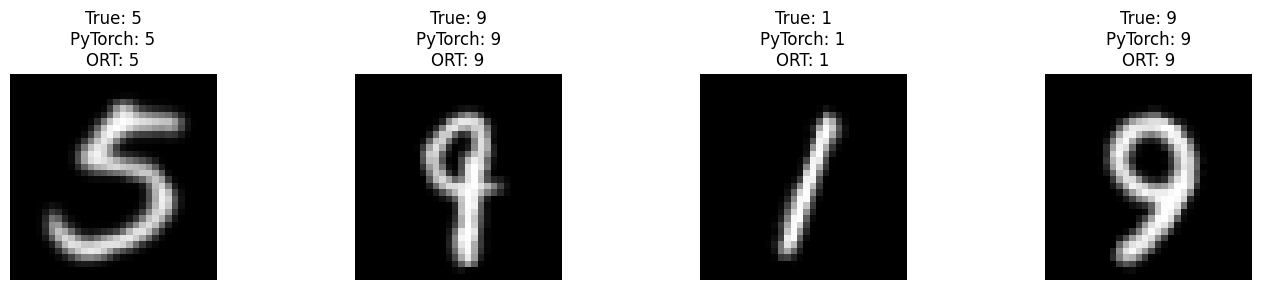

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for i in range(4):
    img = test_images[i].squeeze().numpy()
    true_label = test_labels[i].item()
    pytorch_pred = pytorch_outputs[i].argmax()
    ort_pred = ort_logits[i].argmax()

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"True: {true_label}\nPyTorch: {pytorch_pred}\nORT: {ort_pred}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [13]:
HF_REPO_ID = "karanravindra/mnist-cnn-onnx"
HF_MODEL_FILE = "mnist_cnn.onnx"

api = HfApi()

api.create_repo(repo_id=HF_REPO_ID, repo_type="model", private=False, exist_ok=True)
api.upload_file(
    path_or_fileobj=str(cfg.onnx_path),
    path_in_repo=HF_MODEL_FILE,
    repo_id=HF_REPO_ID,
    repo_type="model",
)

model_url = (
    f"https://huggingface.co/{HF_REPO_ID}/resolve/main/{HF_MODEL_FILE}?download=1"
)
print(f"Model uploaded: {model_url}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model uploaded: https://huggingface.co/karanravindra/mnist-cnn-onnx/resolve/main/mnist_cnn.onnx?download=1
